In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

In [4]:
train_path = "data/train/"
sunny_path = os.path.join(train_path, "sunny")
cloud_path = os.path.join(train_path, "cloudy")

---

In [5]:
# 2. Φόρτωση δεδομένων και στατιστική ανάλυση
def analyze_images(folder_path):
    sizes = []
    means = []
    stds = []
    red_values = []
    green_values = []
    blue_values = []
    
    for img_file in os.listdir(folder_path):
        if img_file.endswith('.jpg'):
            img_path = os.path.join(folder_path, img_file)
            with Image.open(img_path) as img:
                img_array = np.array(img)
                
                # Basic image characteristics
                sizes.append(img_array.shape)
                
                # Color channels (if RGB)
                if len(img_array.shape) == 3:  # Color image
                    red = img_array[:,:,0].flatten()
                    green = img_array[:,:,1].flatten()
                    blue = img_array[:,:,2].flatten()
                else:  # Grayscale
                    red = green = blue = img_array.flatten()
                
                red_values.extend(red)
                green_values.extend(green)
                blue_values.extend(blue)
                
                # Mean and standard deviation
                means.append(np.mean(img_array))
                stds.append(np.std(img_array))
    
    return {
        'sizes': sizes,
        'means': means,
        'stds': stds,
        'red_values': red_values,
        'green_values': green_values,
        'blue_values': blue_values
    }

In [6]:
# Ανάλυση και για τις δύο κλάσεις
sunny_stats = analyze_images(sunny_path)
print("Sunny Images Statistics done.")
cloud_stats = analyze_images(cloud_path)
print("Cloudy Images Statistics done.")

Sunny Images Statistics done.
Cloudy Images Statistics done.


----

In [ ]:
# 3. Στατιστική περιγραφή
def create_rgb_stats_df(stats_dict, class_name):
    # Create a dictionary with the RGB statistics
    stats = {
        'Red': {
            'mean': np.mean(stats_dict['red_values']),
            'median': np.median(stats_dict['red_values']),
            'std': np.std(stats_dict['red_values']),
            'min': np.min(stats_dict['red_values']),
            'max': np.max(stats_dict['red_values']),
            'percentile_25': np.percentile(stats_dict['red_values'], 25),
            'percentile_75': np.percentile(stats_dict['red_values'], 75)
        },
        'Green': {
            'mean': np.mean(stats_dict['green_values']),
            'median': np.median(stats_dict['green_values']),
            'std': np.std(stats_dict['green_values']),
            'min': np.min(stats_dict['green_values']),
            'max': np.max(stats_dict['green_values']),
            'percentile_25': np.percentile(stats_dict['green_values'], 25),
            'percentile_75': np.percentile(stats_dict['green_values'], 75)
        },
        'Blue': {
            'mean': np.mean(stats_dict['blue_values']),
            'median': np.median(stats_dict['blue_values']),
            'std': np.std(stats_dict['blue_values']),
            'min': np.min(stats_dict['blue_values']),
            'max': np.max(stats_dict['blue_values']),
            'percentile_25': np.percentile(stats_dict['blue_values'], 25),
            'percentile_75': np.percentile(stats_dict['blue_values'], 75)
        }
    }
    
    # Create DataFrame
    df = pd.DataFrame(stats).T
    
    # Format the output
    print(f"\nΣτατιστική Περιγραφή Καναλιών RGB ({class_name}):")
    print(df.to_string(float_format="%.6f"))
    
    return df
    
    
sunny_rgb_df = create_rgb_stats_df(sunny_stats, "Sunny")
cloud_rgb_df = create_rgb_stats_df(cloud_stats, "Cloud")

---

In [ ]:
def plot_class_distribution():
    sunny_count = len([f for f in os.listdir(sunny_path) if f.endswith('.jpg')])
    cloud_count = len([f for f in os.listdir(cloud_path) if f.endswith('.jpg')])
    
    plt.figure(figsize=(8, 6))
    plt.bar(['Sunny', 'Cloud'], [sunny_count, cloud_count], color=['gold', 'gray'])
    plt.title('Class Distribution')
    plt.ylabel('Number of Images')
    plt.show()
    
    # Calculate percentages
    total = sunny_count + cloud_count
    print(f"\nClass balance analysis:")
    print(f"Sunny: {sunny_count} images ({sunny_count/total*100:.2f}%)")
    print(f"Cloud: {cloud_count} images ({cloud_count/total*100:.2f}%)")
    
    # Check for class imbalance (typically considered imbalanced when ratio > 2:1)
    if max(sunny_count, cloud_count) / min(sunny_count, cloud_count) > 2:
        print("\nWARNING: Significant class imbalance detected!")
    else:
        print("\nClasses are relatively balanced.")

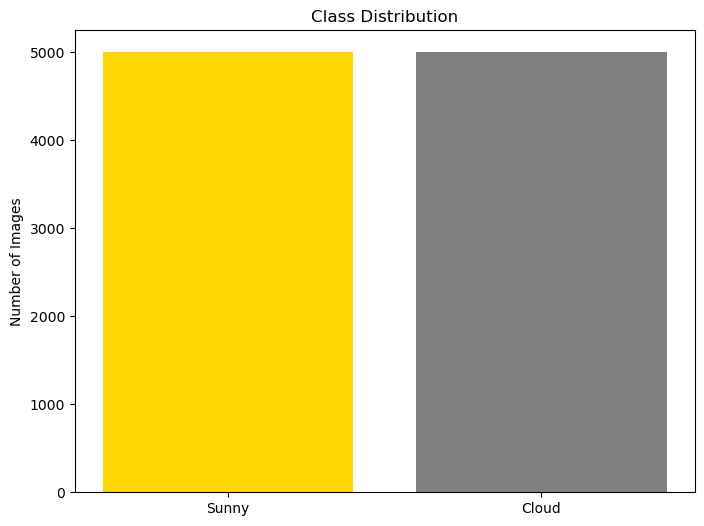


Class balance analysis:
Sunny: 5000 images (50.00%)
Cloud: 5000 images (50.00%)

Classes are relatively balanced.


In [ ]:
plot_class_distribution()

In [ ]:
# def analyze_color_channels():
#     fig, axes = plt.subplots(2, 3, figsize=(15, 10))
#     fig.suptitle('Color Channel Distribution by Class')
    
#     # Sunny class
#     axes[0,0].hist(sunny_stats['red_values'], bins=50, color='red', alpha=0.7)
#     axes[0,0].set_title('Sunny - Red Channel')
    
#     axes[0,1].hist(sunny_stats['green_values'], bins=50, color='green', alpha=0.7)
#     axes[0,1].set_title('Sunny - Green Channel')
    
#     axes[0,2].hist(sunny_stats['blue_values'], bins=50, color='blue', alpha=0.7)
#     axes[0,2].set_title('Sunny - Blue Channel')
    
#     # Cloud class
#     axes[1,0].hist(cloud_stats['red_values'], bins=50, color='red', alpha=0.7)
#     axes[1,0].set_title('Cloud - Red Channel')
    
#     axes[1,1].hist(cloud_stats['green_values'], bins=50, color='green', alpha=0.7)
#     axes[1,1].set_title('Cloud - Green Channel')
    
#     axes[1,2].hist(cloud_stats['blue_values'], bins=50, color='blue', alpha=0.7)
#     axes[1,2].set_title('Cloud - Blue Channel')
    
#     plt.tight_layout()
#     plt.show()
    
#     # Check for outliers in brightness means
#     plt.figure(figsize=(10, 6))
#     plt.boxplot([sunny_stats['means'], cloud_stats['means']], labels=['Sunny', 'Cloud'])
#     plt.title('Range of Mean Brightness Values by Class')
#     plt.ylabel('Mean pixel value')
#     plt.show()
    
#     # Identify outliers using IQR rule
#     def detect_outliers(data):
#         q1 = np.percentile(data, 25)
#         q3 = np.percentile(data, 75)
#         iqr = q3 - q1
#         lower_bound = q1 - 1.5 * iqr
#         upper_bound = q3 + 1.5 * iqr
#         outliers = [x for x in data if x < lower_bound or x > upper_bound]
#         return outliers
    
#     sunny_outliers = detect_outliers(sunny_stats['means'])
#     cloud_outliers = detect_outliers(cloud_stats['means'])
    
#     print(f"\nOutliers in mean brightness:")
#     print(f"Sunny: {len(sunny_outliers)} outliers ({len(sunny_outliers)/len(sunny_stats['means'])*100:.2f}%)")
#     print(f"Cloud: {len(cloud_outliers)} outliers ({len(cloud_outliers)/len(cloud_stats['means'])*100:.2f}%)")

In [ ]:
# analyze_color_channels()